# Predicting Housing Prices with Linear Regression

## (A)  Data Exploration and Pre-processing

In [1]:
import pandas as pd

df = pd.read_csv("USA_Housing.csv")

print("The first 5 rows of the dataset：")
print(df.head())

The first 5 rows of the dataset：
   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0      79545.458574             5.682861                   7.009188   
1      79248.642455             6.002900                   6.730821   
2      61287.067179             5.865890                   8.512727   
3      63345.240046             7.188236                   5.586729   
4      59982.197226             5.040555                   7.839388   

   Avg. Area Number of Bedrooms  Area Population         Price  \
0                          4.09     23086.800503  1.059034e+06   
1                          3.09     40173.072174  1.505891e+06   
2                          5.13     36882.159400  1.058988e+06   
3                          3.26     34310.242831  1.260617e+06   
4                          4.23     26354.109472  6.309435e+05   

                                             Address  
0  208 Michael Ferry Apt. 674\nLaurabury, NE 3701...  
1  188 Johnson Views Suite 079\nL

Based on the first five rows, the dataset contains six numerical variables and one text variable. The target variable is "Price".

In [2]:
print("\n Informations, Data Type, Non-null Values：")
print(df.info())

print("\n Descriptive statistics for numerical columns：")
print(df.describe())

print("\n Count of missing values per column：")
missing_count = df.isnull().sum()
print(missing_count)


 Informations, Data Type, Non-null Values：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB
None

 Descriptive statistics for numerical columns：
       Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
count       5000.000000          5000.000000                5000.000000   
mean       68583.108984             5.977222                  

This dataset contains 5,000 housing records, the data in all columns is complete, with no missing values.

In [3]:
feature_columns = [
    "Avg. Area Income",
    "Avg. Area House Age",
    "Avg. Area Number of Rooms",
    "Avg. Area Number of Bedrooms",
    "Area Population"
]
X = df[feature_columns]
y = df["Price"]

print("Shape of the feature matrix X：", X.shape)
print("Shape of the feature matrix y：", y.shape)

Shape of the feature matrix X： (5000, 5)
Shape of the feature matrix y： (5000,)


In [4]:
df["Avg_Area_Room_Per_Person"] = df["Avg. Area Number of Rooms"] / df["Avg. Area Number of Bedrooms"]
print(df[["Avg. Area Number of Rooms", "Avg. Area Number of Bedrooms", "Avg_Area_Room_Per_Person"]].head())

   Avg. Area Number of Rooms  Avg. Area Number of Bedrooms  \
0                   7.009188                          4.09   
1                   6.730821                          3.09   
2                   8.512727                          5.13   
3                   5.586729                          3.26   
4                   7.839388                          4.23   

   Avg_Area_Room_Per_Person  
0                  1.713738  
1                  2.178259  
2                  1.659401  
3                  1.713720  
4                  1.853283  


I believe adding this attribute is beneficial. Since a home requires spaces for activities other than sleeping, such as a study or a living room, having fewer bedrooms is likely to increase the property value.

In [5]:
# Extract the 5-digit ZIP code from the Address column
df["ZipCode"] = df["Address"].str.extract(r'(\d{5})')

# Convert to numeric
df["ZipCode"] = pd.to_numeric(df["ZipCode"])
print(df[["Address", "ZipCode"]].head())

                                             Address  ZipCode
0  208 Michael Ferry Apt. 674\nLaurabury, NE 3701...    37010
1  188 Johnson Views Suite 079\nLake Kathleen, CA...    48958
2  9127 Elizabeth Stravenue\nDanieltown, WI 06482...     6482
3                          USS Barnett\nFPO AP 44820    44820
4                         USNS Raymond\nFPO AE 09386     9386


ZIP codes may capture geographical information. Since housing prices often vary by location, this feature may improve the prediction performance.

In [6]:
# Outlier Detection
import seaborn as sns
import numpy as np
from scipy import stats

price = df["Price"]

# Calculate quartiles
Q1 = price.quantile(0.25)
Q3 = price.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Mark outliers
outliers_mask = (price < lower_bound) | (price > upper_bound)
outliers = df[outliers_mask]
normal_data = df[~outliers_mask]

print(f"IQR method：{len(outliers)}")
print(f"Number of normal data points：{len(normal_data)}")
print(f"lower bounds:{lower_bound:.2f}, Upper bounds:{upper_bound:.2f}")

IQR method：35
Number of normal data points：4965
lower bounds:287127.53, Upper bounds:2181659.81


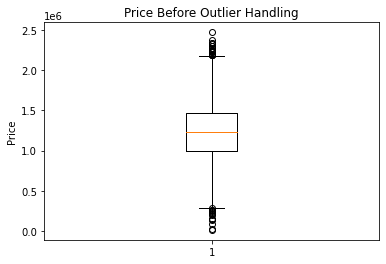

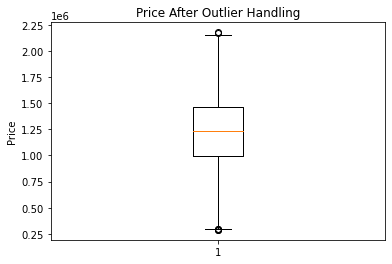

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(df["Price"])
plt.title("Price Before Outlier Handling")
plt.ylabel("Price")
plt.show()

plt.figure(figsize=(6,4))
plt.boxplot(normal_data["Price"])
plt.title("Price After Outlier Handling")
plt.ylabel("Price")
plt.show()

A comparison of the box plots before and after the removal reveals that the data distribution has become more compact, which is expected to enhance the model's robustness.

## (B) Linear Regression Model

In [8]:
from sklearn.model_selection import train_test_split

# Features
X = normal_data[['Avg. Area Income',
                 'Avg. Area House Age',
                 'Avg. Area Number of Rooms',
                 'Avg. Area Number of Bedrooms',
                 'Area Population',
                 'Avg_Area_Room_Per_Person']]

# Target
y = normal_data['Price']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression() # Create a Linear Regression model

model.fit(X_train, y_train) # Train the model

y_pred = model.predict(X_test) # Predict house prices on the test set

print("First 3 predicted prices:") # Display the first 3 predictions
print(y_pred[:3])

First 3 predicted prices:
[1083850.90435661 1174535.89909789 1032537.23884014]


## (C) Model Evaluation

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"TEST_MAE: {mae:.2f}")
print(f"TEST_MSE: {mse:.2f}")

TEST_MAE: 81116.03
TEST_MSE: 10249393760.70


In [12]:
import numpy as np

rmse = np.sqrt(mse)

print(f"RMSE: {rmse:.2f}")

RMSE: 101239.29


In [13]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f"R²: {r2:.4f}")

R²: 0.9064


The linear regression model performs well for predicting housing prices, with an R² of 0.9064 meaning our features explain over 90% of price changes. The MAE and RMSE indicate that the prediction errors are relatively small compared with the average house price. So, the model captures most price patterns but still makes big mistakes on some extreme homes.

In [14]:
from sklearn.model_selection import cross_val_score

lr_model = LinearRegression()

cv_r2 = cross_val_score(lr_model, X, y, cv=5, scoring="r2")
cv_rmse = -cross_val_score(lr_model, X, y, cv=5, scoring="neg_root_mean_squared_error")

print(f"Each fold R²: {cv_r2.round(4)}")
print(f"Average R²: {np.mean(cv_r2):.4f}")

print(f"Each fold RMSE: {cv_rmse.round(2)}")
print(f"Average RMSE: {np.mean(cv_rmse):.2f}")

Each fold R²: [0.9098 0.914  0.9102 0.9193 0.9123]
Average R²: 0.9131
Each fold RMSE: [100091.74 103063.78  99955.07 100371.64 101885.3 ]
Average RMSE: 101073.51


The average R² of 0.9131 is slightly higher than the result from the single train-test split, indicating good model generalization. The average RMSE of 101,073.51 is very close to the test RMSE. This shows that the model is stable and that cross-validation provides a more reliable performance evaluation. Compared to a single data split, cross-validation reduces the impact of random partitioning. It makes more effective use of available data and provides a more reliable assessment of model performance.

## (D) Coefficients and Intercept

In [15]:
# Display the coefficients of each feature
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("Linear Regression Coefficients:")
print(coefficients)

print("\nIntercept:")
print(model.intercept_)

Linear Regression Coefficients:
                        Feature    Coefficient
0              Avg. Area Income      21.512407
1           Avg. Area House Age  165819.932116
2     Avg. Area Number of Rooms  119602.034858
3  Avg. Area Number of Bedrooms    1036.480492
4               Area Population      15.130842
5      Avg_Area_Room_Per_Person   -4278.135920

Intercept:
-2613715.1884487295


Most features have positive coefficients, indicating that higher values of these features are associated with higher housing prices. The engineered feature Avg_Area_Room_Per_Person has a small negative coefficient, which may be due to its strong correlation with the existing room related features.

Avg. Area Income coefficient = 21.51; If average local income rises by 1 dollar, the predicted housing price increases by $21.51. Higher neighborhood income lifts home values.

Avg. Area House Age; Each extra year of average house age adds $165,819.93 to predicted price. Older neighborhoods property values are much higher. This feature has the strongest positive impact on price.

Avg. Area Number of Rooms; One more room raises predicted price by $119,602.03. Larger homes with more rooms sell for far more money. This is the second most powerful positive factor.

Avg. Area Number of Bedrooms; Adding one bedroom increases predicted price by $1,036.48. More bedrooms slightly boost price, but the effect is very small compared to total room count.

Area Population; Each extra local resident pushes predicted price up by $15.13. Denser areas have stronger housing demand and better public facilities, leading to slightly higher prices.

Intercept = -2613715.19; The intercept is the base predicted price when every feature equals zero. But a neighborhood with zero income, zero rooms and zero population cannot exist in reality.